# WGAN paper figure 2 reproduction

This notebook reproduces the example comparing:
- Simple GANs
- rolled GANs (with different discriminator to generator training steps)
- Wasserstein GANs

For a distribution of 8 normals cenered around a circle
- radius = 2.0
- std of normal = 0.05

In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


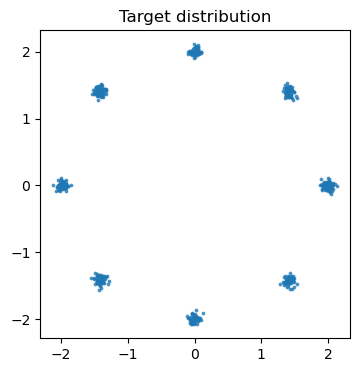

In [ ]:
# 8 Gaussians on a circle
RADIUS = 2.0
STD    = 0.05
N_MODES = 8

CENTERS = np.array([
    (RADIUS * np.cos(2 * np.pi * k / N_MODES),
     RADIUS * np.sin(2 * np.pi * k / N_MODES))
    for k in range(N_MODES)
], dtype=np.float32)

def sample_real(n):
    idx = np.random.randint(0, N_MODES, size=n)
    return (CENTERS[idx] + np.random.randn(n, 2).astype(np.float32) * STD)

# Visualize 500 samples from the distribution
real_check = sample_real(500)
plt.figure(figsize=(4, 4))
plt.scatter(real_check[:, 0], real_check[:, 1], s=3, alpha=0.7)
plt.axis('equal'); plt.title('Target distribution'); plt.show()

In [ ]:
# to stress test it, we constrant the architecture to only 2 layers with 8 hidden units to see how each type of GAN performs
# A better architecture was showing identical performance for all models as they are able to learn it very easily

def make_generator():
    """Small MLP: 2 → 8 → 8 → 2"""
    return nn.Sequential(
        nn.Linear(2, 8), nn.Tanh(),
        nn.Linear(8, 8),       nn.Tanh(),
        nn.Linear(8, 2)
    )

def make_discriminator():
    """Standard GAN discriminator with sigmoid."""
    return nn.Sequential(
        nn.Linear(2, 8),   nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 1),   nn.Sigmoid()
    )

def make_critic():
    """WGAN critic : no sigmoid, Uses Wasserstein distance later"""
    return nn.Sequential(
        nn.Linear(2, 8),   nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 1)
    )

def znoise(n):
    return torch.randn(n, 2, device=device)

def rt(arr):
    """numpy → tensor on device"""
    return torch.tensor(arr, device=device)

def get_fake(G, n=512):
    G.eval()
    with torch.no_grad():
        s = G(znoise(n)).cpu().numpy()
    G.train()
    return s

In [ ]:
PLOT_RANGE   = 3.0          # axis limits
KDE_BW       = 0.08         # bandwidth of the kernel density estimate
KDE_GRID     = 120
EPOCHS_PLOT  = [0, 1, 5, 10, 20, 50, 100]

# Pre-build grid once
_x = np.linspace(-PLOT_RANGE, PLOT_RANGE, KDE_GRID)
_y = np.linspace(-PLOT_RANGE, PLOT_RANGE, KDE_GRID)
_xx, _yy = np.meshgrid(_x, _y)
_grid = np.vstack([_xx.ravel(), _yy.ravel()])

def draw_kde(ax, pts):
    ax.set_facecolor('#f0faf0')
    ax.set_xlim(-PLOT_RANGE, PLOT_RANGE)
    ax.set_ylim(-PLOT_RANGE, PLOT_RANGE)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    if pts is None or len(pts) < 10:
        return
    try:
        kde = gaussian_kde(pts.T, bw_method=KDE_BW)
        zz  = kde(_grid).reshape(_xx.shape)
        ax.contourf(_xx, _yy, zz, levels=12,
                    cmap='Greens', vmin=0)
    except Exception:
        pass

def draw_samples(ax, pts):
    ax.set_facecolor('white')
    ax.set_xlim(-PLOT_RANGE, PLOT_RANGE)
    ax.set_ylim(-PLOT_RANGE, PLOT_RANGE)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    if pts is None:
        return
    ax.scatter(pts[:, 0], pts[:, 1],
               s=3, c='royalblue', alpha=0.6, linewidths=0)

In [ ]:
# train the standard GAN

BATCH    = 64
STEPS_EP = 100
LR_GAN   = 2e-4

std_snap = {}

G_s = make_generator().to(device)
D_s = make_discriminator().to(device)
oG  = optim.Adam(G_s.parameters(), lr=LR_GAN, betas=(0.5, 0.9))
oD  = optim.Adam(D_s.parameters(), lr=LR_GAN, betas=(0.5, 0.9))
bce = nn.BCELoss()
ones  = lambda n: torch.ones(n, 1, device=device)
zeros = lambda n: torch.zeros(n, 1, device=device)

std_snap[0] = get_fake(G_s)

for ep in range(1, 101):
    for _ in range(STEPS_EP):
        real = rt(sample_real(BATCH))
        z    = znoise(BATCH)
        fake = G_s(z).detach()

        # D step
        ld = bce(D_s(real), ones(BATCH)) + bce(D_s(fake), zeros(BATCH))
        oD.zero_grad(); ld.backward(); oD.step()

        # G step (maximize log D(G(z)))
        lg = bce(D_s(G_s(znoise(BATCH))), ones(BATCH))
        oG.zero_grad(); lg.backward(); oG.step()

    if ep in EPOCHS_PLOT:
        std_snap[ep] = get_fake(G_s)
        print(f'StdGAN  ep {ep:3d}')

print('Standard GAN done.')

StdGAN  ep   1
StdGAN  ep   5
StdGAN  ep  10
StdGAN  ep  20
StdGAN  ep  50
StdGAN  ep 100
Standard GAN done.


In [ ]:
# Unrolled GAN

UNROLL_K = 5
LR_UNR   = 2e-4

unr_snap = {}

G_u = make_generator().to(device)
D_u = make_discriminator().to(device)
oGu = optim.Adam(G_u.parameters(), lr=LR_UNR, betas=(0.5, 0.9))
oDu = optim.Adam(D_u.parameters(), lr=LR_UNR, betas=(0.5, 0.9))

unr_snap[0] = get_fake(G_u)

def d_loss_fn(D, G, n):
    r = rt(sample_real(n))
    f = G(znoise(n)).detach()
    return bce(D(r), ones(n)) + bce(D(f), zeros(n))

for ep in range(1, 101):
    for _ in range(STEPS_EP):
        # Standard D step
        ld = d_loss_fn(D_u, G_u, BATCH)
        oDu.zero_grad(); ld.backward(); oDu.step()

        # Unroll: clone D, do K more updates on clone
        D_clone  = deepcopy(D_u)
        o_clone  = optim.Adam(D_clone.parameters(), lr=LR_UNR, betas=(0.5, 0.9))
        for _ in range(UNROLL_K):
            lk = d_loss_fn(D_clone, G_u, BATCH)
            o_clone.zero_grad(); lk.backward(); o_clone.step()

        # G update against unrolled D clone
        lg = bce(D_clone(G_u(znoise(BATCH))), ones(BATCH))
        oGu.zero_grad(); lg.backward(); oGu.step()

    if ep in EPOCHS_PLOT:
        unr_snap[ep] = get_fake(G_u)
        print(f'UnrolledGAN ep {ep:3d}')

print('Unrolled GAN done.')

UnrolledGAN ep   1
UnrolledGAN ep   5
UnrolledGAN ep  10
UnrolledGAN ep  20
UnrolledGAN ep  50
UnrolledGAN ep 100
Unrolled GAN done.


In [ ]:
# Wasserstein GAN

WGAN_LR      = 2e-4
WGAN_CLIP    = 0.05 # clipping weight
WGAN_NCRIT   = 5 # number of critic updates per generator updates
WGAN_BATCH   = 64
WGAN_STEPS   = 100

wgan_snap = {}

G_w = make_generator().to(device)
C_w = make_critic().to(device)
oGw = optim.RMSprop(G_w.parameters(), lr=WGAN_LR)
oCw = optim.RMSprop(C_w.parameters(), lr=WGAN_LR)

wgan_snap[0] = get_fake(G_w)

for ep in range(1, 101):
    for _ in range(WGAN_STEPS):
        # Train critic n_critic times
        for _ in range(WGAN_NCRIT):
            real = rt(sample_real(WGAN_BATCH))
            z    = znoise(WGAN_BATCH)
            lc   = -(C_w(real).mean() - C_w(G_w(z).detach()).mean())
            oCw.zero_grad(); lc.backward(); oCw.step()
            for p in C_w.parameters():
                p.data.clamp_(-WGAN_CLIP, WGAN_CLIP)

        # Train generator
        lg = -C_w(G_w(znoise(WGAN_BATCH))).mean()
        oGw.zero_grad(); lg.backward(); oGw.step()

    if ep in EPOCHS_PLOT:
        wgan_snap[ep] = get_fake(G_w)
        print(f'WGAN    ep {ep:3d}')

print('WGAN done.')

WGAN    ep   1
WGAN    ep   5
WGAN    ep  10
WGAN    ep  20
WGAN    ep  50
WGAN    ep 100
WGAN done.


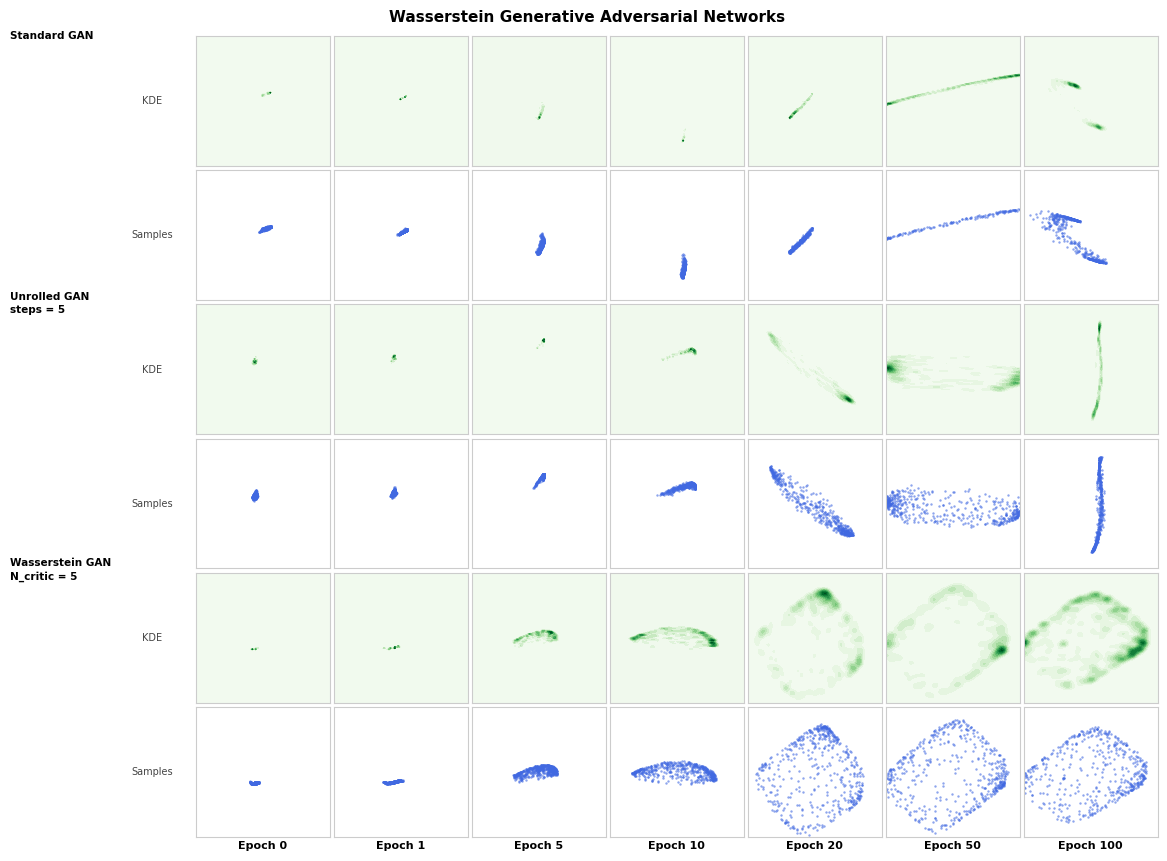

Saved figure2_wgan_v2.png


In [ ]:
# Plot figure
ROWS = [
    ('Standard GAN',              'KDE',     std_snap,  draw_kde),
    ('Standard GAN',              'Samples', std_snap,  draw_samples),
    ('Unrolled GAN\nsteps = 5',   'KDE',     unr_snap,  draw_kde),
    ('Unrolled GAN\nsteps = 5',   'Samples', unr_snap,  draw_samples),
    ('Wasserstein GAN\nN_critic = 5', 'KDE',     wgan_snap, draw_kde),
    ('Wasserstein GAN\nN_critic = 5', 'Samples', wgan_snap, draw_samples),
]
EPOCHS = EPOCHS_PLOT  # 7 columns

CELL = 1.35   # inches per cell
fig_w = CELL * len(EPOCHS) + 2.2
fig_h = CELL * len(ROWS)   + 0.7

fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white')
fig.suptitle('Wasserstein Generative Adversarial Networks',
             fontsize=11, fontweight='bold', y=0.995)

gs = gridspec.GridSpec(
    len(ROWS), len(EPOCHS),
    left=0.165, right=0.99,
    top=0.965, bottom=0.055,
    hspace=0.035, wspace=0.035
)

prev_method = None

for ri, (method, row_type, snap, draw_fn) in enumerate(ROWS):
    for ci, ep in enumerate(EPOCHS):
        ax = fig.add_subplot(gs[ri, ci])
        draw_fn(ax, snap.get(ep))

        # Epoch label on bottom row
        if ri == len(ROWS) - 1:
            ax.set_xlabel(f'Epoch {ep}', fontsize=8, fontweight='bold', labelpad=3)

        # Row-type label (KDE / Samples) on the right edge of left margin
        if ci == 0:
            ax.set_ylabel(row_type, fontsize=7, rotation=0,
                          labelpad=32, va='center', color='#444')

    # Method label: only once per pair of rows, centred between them
    if method != prev_method:
        top_val  = 0.965
        bot_val  = 0.055
        row_h    = (top_val - bot_val) / len(ROWS)
        cy       = top_val - (ri + 1) * row_h + row_h   # centre of pair
        fig.text(0.005, cy, method,
                 fontsize=7.5, fontweight='bold', va='center', ha='left',
                 linespacing=1.4)
        prev_method = method

plt.savefig('figure2_wgan_v2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved figure2_wgan_v2.png')

As we see. WGAN is able to learn the distribution _extremely effeciently_ even with a very constrained architecure \
GAN and Unrolled GAN are not able to do so